# Notebook B (COLAB) — Attention U-Net + Baseline + Ablation + Evaluación

Versión para **Google Colab con GPU** (Entorno de ejecución → Cambiar tipo → T4 GPU).
Lee los parches que el Notebook A dejó en `MyDrive/deforestacion_ucayali/parches/`.

| Modelo | Arquitectura | Loss | Rol |
|---|---|---|---|
| Baseline | U-Net | BCE | referencia |
| Ablation | U-Net | Dice | aísla el efecto del loss |
| Propuesto | Attention U-Net | Dice | hipótesis del trabajo |

La evaluación en test descompone la mejora de IoU en *efecto del loss* vs *efecto de la atención*.

## Celda 1 — Setup (Drive + GPU)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, glob
DIR_DRIVE_PARCHES = '/content/drive/MyDrive/deforestacion_ucayali/parches'
for split in ['train', 'val', 'test']:
    ruta = f'{DIR_DRIVE_PARCHES}/{split}'
    if os.path.exists(ruta):
        print(f'  {split}: {len(glob.glob(f"{ruta}/*.npy"))} parches')
    else:
        print(f'  No existe: {ruta}  (corre primero el Notebook A)')

  train: 1004 parches
  val: 207 parches
  test: 236 parches


## Celda 2 — Imports, rutas y device

In [3]:
import os, glob, time, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

DIR_DRIVE_PARCHES = '/content/drive/MyDrive/deforestacion_ucayali/parches'
DIR_RESULTADOS    = '/content/drive/MyDrive/deforestacion_ucayali/resultados'
os.makedirs(DIR_RESULTADOS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('AVISO: sin GPU. Entorno de ejecucion -> Cambiar tipo -> T4 GPU.')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

Device: cuda
GPU: Tesla T4


## Celda 3 — Copiar parches al disco local de Colab (lectura rápida)

In [4]:
import shutil
DIR_PARCHES = '/content/parches'   # disco local de Colab: mucho mas rapido que Drive
for split in ['train', 'val', 'test']:
    os.makedirs(f'{DIR_PARCHES}/{split}', exist_ok=True)
    src = sorted(glob.glob(f'{DIR_DRIVE_PARCHES}/{split}/*.npy'))
    print(f'Copiando {split}: {len(src)} parches...')
    for r in src:
        d = f'{DIR_PARCHES}/{split}/{os.path.basename(r)}'
        if not os.path.exists(d):
            shutil.copy(r, d)
print('Listo. Leyendo parches desde', DIR_PARCHES)

Copiando train: 1004 parches...
Copiando val: 207 parches...
Copiando test: 236 parches...
Listo. Leyendo parches desde /content/parches


## Celda 4 — Dataset, normalización y DataLoaders

z-score por canal con estadísticas calculadas SOLO sobre train (sin fuga a val/test).

In [5]:
class DatasetDeforestacion(Dataset):
    def __init__(self, rutas, media=None, std=None, augment=False):
        self.rutas = rutas; self.media = media; self.std = std; self.augment = augment
    def __len__(self): return len(self.rutas)
    def __getitem__(self, idx):
        arr = np.load(self.rutas[idx])
        x = arr[:12].astype(np.float32)
        y = arr[12].astype(np.float32)
        x = np.where(np.abs(x) > 1e30, 0.0, x)   # defensa: saneo de cualquier nodata-sentinel
        if self.media is not None:
            x = (x - self.media[:, None, None]) / (self.std[:, None, None] + 1e-6)
        if self.augment:
            if random.random() < 0.5: x = x[:, :, ::-1].copy(); y = y[:, ::-1].copy()
            if random.random() < 0.5: x = x[:, ::-1, :].copy(); y = y[::-1, :].copy()
            k = random.randint(0, 3); x = np.rot90(x, k, axes=(1,2)).copy(); y = np.rot90(y, k).copy()
        return torch.from_numpy(x), torch.from_numpy(y).unsqueeze(0)

rutas_train = sorted(glob.glob(f'{DIR_PARCHES}/train/*.npy'))
rutas_val   = sorted(glob.glob(f'{DIR_PARCHES}/val/*.npy'))
rutas_test  = sorted(glob.glob(f'{DIR_PARCHES}/test/*.npy'))
print(f'Train: {len(rutas_train)} | Val: {len(rutas_val)} | Test: {len(rutas_test)}')

print('Calculando media/std sobre train...')
muestras = np.stack([np.load(r)[:12] for r in random.sample(rutas_train, min(200, len(rutas_train)))])
muestras = np.where(np.abs(muestras) > 1e30, 0.0, muestras)
media = muestras.mean(axis=(0,2,3)).astype(np.float32)
std   = muestras.std(axis=(0,2,3)).astype(np.float32)
print('Media:', media)
print('Std  :', std)
np.savez(f'{DIR_RESULTADOS}/normalizacion.npz', media=media, std=std)

BATCH = 8
ds_train = DatasetDeforestacion(rutas_train, media, std, augment=True)
ds_val   = DatasetDeforestacion(rutas_val,   media, std, augment=False)
ds_test  = DatasetDeforestacion(rutas_test,  media, std, augment=False)
dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

Train: 1004 | Val: 207 | Test: 236
Calculando media/std sobre train...
Media: [ 0.03321387  0.05309909  0.03491115  0.285759    0.75878006 -0.2414668
  0.03560013  0.05516345  0.03763261  0.28935373  0.7479629  -0.2281918 ]
Std  : [0.01538492 0.01927413 0.02623909 0.06947628 0.23946984 0.12788758
 0.0162696  0.02001295 0.02780985 0.06816317 0.23985784 0.12604629]


In [10]:
print('Verificando la integridad de los archivos .npy...')
expected_shape = (13, 256, 256)
problematic_files = []

for split_name, rutas in [('train', rutas_train), ('val', rutas_val), ('test', rutas_test)]:
    print(f'  Verificando parches de {split_name}...')
    for i, ruta_parche in enumerate(rutas):
        try:
            arr = np.load(ruta_parche)
            if arr.shape != expected_shape:
                print(f'    ¡Advertencia! Archivo con forma inesperada: {ruta_parche} - Forma: {arr.shape} (esperado: {expected_shape})')
                problematic_files.append((ruta_parche, arr.shape))
            # Check if reshaping x and y would cause an error, even if overall shape is fine (e.g., if channels are wrong)
            try:
                x = arr[:12]
                y = arr[12]
                if x.shape != (12, 256, 256) or y.shape != (256, 256):
                    print(f'    ¡Advertencia! Archivo con sub-formas inesperadas: {ruta_parche} - x.shape: {x.shape}, y.shape: {y.shape}')
                    problematic_files.append((ruta_parche, (x.shape, y.shape)))
            except IndexError:
                print(f'    ¡Error! Archivo con menos de 13 canales: {ruta_parche} - Forma: {arr.shape}')
                problematic_files.append((ruta_parche, 'menos de 13 canales'))

        except ValueError as e:
            print(f'    ¡Error! Problema al cargar o interpretar el archivo: {ruta_parche} - Error: {e}')
            problematic_files.append((ruta_parche, str(e)))
        except Exception as e:
            print(f'    ¡Error inesperado! al procesar el archivo: {ruta_parche} - Error: {e}')
            problematic_files.append((ruta_parche, str(e)))

if problematic_files:
    print('\nSe encontraron los siguientes problemas:')
    for f, issue in problematic_files:
        print(f'  - {f}: {issue}')
    print('\nPor favor, revisa o regenera estos archivos .npy.')
else:
    print('\nTodos los archivos .npy verificados tienen la forma esperada.')


Verificando la integridad de los archivos .npy...
  Verificando parches de train...
    ¡Error! Problema al cargar o interpretar el archivo: /content/parches/train/parche_000000_003328.npy - Error: cannot reshape array of size 787424 into shape (13,256,256)
    ¡Error inesperado! al procesar el archivo: /content/parches/train/parche_005120_005888.npy - Error: No data left in file
  Verificando parches de val...
  Verificando parches de test...

Se encontraron los siguientes problemas:
  - /content/parches/train/parche_000000_003328.npy: cannot reshape array of size 787424 into shape (13,256,256)
  - /content/parches/train/parche_005120_005888.npy: No data left in file

Por favor, revisa o regenera estos archivos .npy.


In [11]:
paths_to_remove = [f for f, issue in problematic_files]
rutas_train = [r for r in rutas_train if r not in paths_to_remove]

print(f'Archivos eliminados de la lista de entrenamiento: {len(paths_to_remove)}')
print(f'Nuevo total de parches de entrenamiento: {len(rutas_train)}')

# Reinicializar el Dataset y DataLoader de entrenamiento
ds_train = DatasetDeforestacion(rutas_train, media, std, augment=True)
dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)

print('DataLoader de entrenamiento actualizado y listo.')

Archivos eliminados de la lista de entrenamiento: 2
Nuevo total de parches de entrenamiento: 1002
DataLoader de entrenamiento actualizado y listo.


El código anterior ha verificado la integridad de tus archivos `.npy`. Si se detectaron problemas, el siguiente paso sería examinar los archivos problemáticos y, si es necesario, regenerarlos usando el "Notebook A" original, asegurándose de que la creación de parches sea consistente.

## Celda 5 — Arquitecturas: U-Net y Attention U-Net

In [12]:
class DobleConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, c_in=12, c_out=1, base=32):
        super().__init__()
        self.e1=DobleConv(c_in,base); self.e2=DobleConv(base,base*2)
        self.e3=DobleConv(base*2,base*4); self.e4=DobleConv(base*4,base*8)
        self.bottleneck=DobleConv(base*8,base*16); self.pool=nn.MaxPool2d(2)
        self.up4=nn.ConvTranspose2d(base*16,base*8,2,stride=2); self.d4=DobleConv(base*16,base*8)
        self.up3=nn.ConvTranspose2d(base*8,base*4,2,stride=2);  self.d3=DobleConv(base*8,base*4)
        self.up2=nn.ConvTranspose2d(base*4,base*2,2,stride=2);  self.d2=DobleConv(base*4,base*2)
        self.up1=nn.ConvTranspose2d(base*2,base,2,stride=2);    self.d1=DobleConv(base*2,base)
        self.out=nn.Conv2d(base,c_out,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.d4(torch.cat([self.up4(b),e4],1)); d3=self.d3(torch.cat([self.up3(d4),e3],1))
        d2=self.d2(torch.cat([self.up2(d3),e2],1)); d1=self.d1(torch.cat([self.up1(d2),e1],1))
        return self.out(d1)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g=nn.Sequential(nn.Conv2d(F_g,F_int,1,bias=False), nn.BatchNorm2d(F_int))
        self.W_x=nn.Sequential(nn.Conv2d(F_l,F_int,1,bias=False), nn.BatchNorm2d(F_int))
        self.psi=nn.Sequential(nn.Conv2d(F_int,1,1,bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu=nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi=self.psi(self.relu(self.W_g(g)+self.W_x(x)))
        return x*psi

class AttentionUNet(nn.Module):
    def __init__(self, c_in=12, c_out=1, base=32):
        super().__init__()
        self.e1=DobleConv(c_in,base); self.e2=DobleConv(base,base*2)
        self.e3=DobleConv(base*2,base*4); self.e4=DobleConv(base*4,base*8)
        self.bottleneck=DobleConv(base*8,base*16); self.pool=nn.MaxPool2d(2)
        self.up4=nn.ConvTranspose2d(base*16,base*8,2,stride=2); self.ag4=AttentionGate(base*8,base*8,base*4); self.d4=DobleConv(base*16,base*8)
        self.up3=nn.ConvTranspose2d(base*8,base*4,2,stride=2);  self.ag3=AttentionGate(base*4,base*4,base*2); self.d3=DobleConv(base*8,base*4)
        self.up2=nn.ConvTranspose2d(base*4,base*2,2,stride=2);  self.ag2=AttentionGate(base*2,base*2,base);   self.d2=DobleConv(base*4,base*2)
        self.up1=nn.ConvTranspose2d(base*2,base,2,stride=2);    self.ag1=AttentionGate(base,base,base//2);     self.d1=DobleConv(base*2,base)
        self.out=nn.Conv2d(base,c_out,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        u4=self.up4(b);  d4=self.d4(torch.cat([u4,self.ag4(u4,e4)],1))
        u3=self.up3(d4); d3=self.d3(torch.cat([u3,self.ag3(u3,e3)],1))
        u2=self.up2(d3); d2=self.d2(torch.cat([u2,self.ag2(u2,e2)],1))
        u1=self.up1(d2); d1=self.d1(torch.cat([u1,self.ag1(u1,e1)],1))
        return self.out(d1)

for nombre, modelo in [('UNet', UNet()), ('AttentionUNet', AttentionUNet())]:
    y = modelo(torch.randn(2,12,256,256))
    print(f'{nombre}: salida {tuple(y.shape)}, params {sum(p.numel() for p in modelo.parameters()):,}')

UNet: salida (2, 1, 256, 256), params 7,765,633
AttentionUNet: salida (2, 1, 256, 256), params 7,853,881


## Celda 6 — Loss (Dice) y métricas (IoU, F1, P, R, Acc)

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1.0):
        super().__init__(); self.eps = eps
    def forward(self, logits, y):
        prob = torch.sigmoid(logits)
        inter = (prob*y).sum(dim=(2,3))
        union = prob.sum(dim=(2,3)) + y.sum(dim=(2,3))
        return 1 - ((2*inter + self.eps)/(union + self.eps)).mean()

def calcular_metricas(logits, y, umbral=0.5):
    pred = (torch.sigmoid(logits) > umbral).float()
    tp = ((pred==1)&(y==1)).sum().item(); fp = ((pred==1)&(y==0)).sum().item()
    fn = ((pred==0)&(y==1)).sum().item(); tn = ((pred==0)&(y==0)).sum().item()
    return tp, fp, fn, tn

def metricas_finales(tp, fp, fn, tn, eps=1e-7):
    precision = tp/(tp+fp+eps); recall = tp/(tp+fn+eps)
    f1 = 2*precision*recall/(precision+recall+eps)
    iou = tp/(tp+fp+fn+eps); accuracy = (tp+tn)/(tp+fp+fn+tn+eps)
    return {'precision':precision, 'recall':recall, 'f1_dice':f1, 'iou':iou, 'accuracy':accuracy}

## Celda 7 — Loop de entrenamiento genérico

In [14]:
def entrenar(modelo, loss_fn, nombre_exp, epocas=20, lr=1e-3):
    modelo = modelo.to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    historial = {'train_loss':[], 'val_loss':[], 'val_iou':[], 'val_f1':[]}
    mejor_iou = -1.0
    ruta_modelo = f'{DIR_RESULTADOS}/{nombre_exp}_best.pt'
    for ep in range(epocas):
        modelo.train(); loss_acum=0.0; n=0; t0=time.time()
        for x, y in dl_train:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); logits = modelo(x); loss = loss_fn(logits, y)
            loss.backward(); opt.step()
            loss_acum += loss.item()*x.size(0); n += x.size(0)
        train_loss = loss_acum/n
        modelo.eval(); loss_acum=0.0; n=0; TP=FP=FN=TN=0
        with torch.no_grad():
            for x, y in dl_val:
                x, y = x.to(device), y.to(device)
                logits = modelo(x); loss = loss_fn(logits, y)
                loss_acum += loss.item()*x.size(0); n += x.size(0)
                tp, fp, fn_, tn = calcular_metricas(logits, y); TP+=tp; FP+=fp; FN+=fn_; TN+=tn
        val_loss = loss_acum/n; m = metricas_finales(TP, FP, FN, TN)
        sched.step(m['iou'])
        historial['train_loss'].append(train_loss); historial['val_loss'].append(val_loss)
        historial['val_iou'].append(m['iou']); historial['val_f1'].append(m['f1_dice'])
        print(f"[{nombre_exp}] Ep {ep+1:02d}/{epocas} | tr {train_loss:.4f} | val {val_loss:.4f} "
              f"| IoU {m['iou']:.4f} | F1 {m['f1_dice']:.4f} | P {m['precision']:.3f} R {m['recall']:.3f} | {time.time()-t0:.0f}s")
        if m['iou'] > mejor_iou:
            mejor_iou = m['iou']; torch.save(modelo.state_dict(), ruta_modelo)
            print(f'  -> guardado (IoU {mejor_iou:.4f})')
    with open(f'{DIR_RESULTADOS}/{nombre_exp}_historial.json', 'w') as f:
        json.dump(historial, f, indent=2)
    return ruta_modelo, historial

## Celda 8 — Experimento 1: Baseline U-Net + BCE

In [15]:
pos_weight = torch.tensor([60.0], device=device)   # compensa el desbalance (~1.6% positivos)
bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
modelo_baseline = UNet(c_in=12, c_out=1, base=32)
ruta_baseline, hist_baseline = entrenar(modelo_baseline, bce, 'unet_baseline', epocas=20, lr=1e-3)

[unet_baseline] Ep 01/20 | tr 1.0801 | val 1.0180 | IoU 0.0372 | F1 0.0717 | P 0.037 R 0.963 | 26s
  -> guardado (IoU 0.0372)
[unet_baseline] Ep 02/20 | tr 0.9667 | val 0.7993 | IoU 0.0802 | F1 0.1485 | P 0.082 R 0.789 | 25s
  -> guardado (IoU 0.0802)
[unet_baseline] Ep 03/20 | tr 0.9343 | val 0.8178 | IoU 0.0632 | F1 0.1190 | P 0.064 R 0.829 | 25s
[unet_baseline] Ep 04/20 | tr 0.9398 | val 0.9198 | IoU 0.0426 | F1 0.0818 | P 0.043 R 0.945 | 26s
[unet_baseline] Ep 05/20 | tr 0.9136 | val 0.8202 | IoU 0.0650 | F1 0.1221 | P 0.066 R 0.834 | 26s
[unet_baseline] Ep 06/20 | tr 0.8969 | val 0.7613 | IoU 0.0748 | F1 0.1392 | P 0.076 R 0.839 | 26s
[unet_baseline] Ep 07/20 | tr 0.8507 | val 0.7972 | IoU 0.0813 | F1 0.1504 | P 0.083 R 0.797 | 26s
  -> guardado (IoU 0.0813)
[unet_baseline] Ep 08/20 | tr 0.8076 | val 0.7195 | IoU 0.0767 | F1 0.1425 | P 0.078 R 0.870 | 26s
[unet_baseline] Ep 09/20 | tr 0.8415 | val 0.7980 | IoU 0.0505 | F1 0.0962 | P 0.051 R 0.918 | 26s
[unet_baseline] Ep 10/20 | t

## Celda 9 — Experimento 2: Attention U-Net + Dice

In [16]:
dice = DiceLoss(eps=1.0)
modelo_attn = AttentionUNet(c_in=12, c_out=1, base=32)
ruta_attn, hist_attn = entrenar(modelo_attn, dice, 'attention_unet_dice', epocas=20, lr=1e-3)

[attention_unet_dice] Ep 01/20 | tr 0.9188 | val 0.9133 | IoU 0.1201 | F1 0.2145 | P 0.127 R 0.698 | 31s
  -> guardado (IoU 0.1201)
[attention_unet_dice] Ep 02/20 | tr 0.8522 | val 0.8471 | IoU 0.1754 | F1 0.2984 | P 0.201 R 0.580 | 30s
  -> guardado (IoU 0.1754)
[attention_unet_dice] Ep 03/20 | tr 0.7992 | val 0.7814 | IoU 0.2241 | F1 0.3662 | P 0.285 R 0.512 | 29s
  -> guardado (IoU 0.2241)
[attention_unet_dice] Ep 04/20 | tr 0.7844 | val 0.7723 | IoU 0.2370 | F1 0.3831 | P 0.321 R 0.476 | 30s
  -> guardado (IoU 0.2370)
[attention_unet_dice] Ep 05/20 | tr 0.7634 | val 0.7583 | IoU 0.2179 | F1 0.3578 | P 0.271 R 0.525 | 30s
[attention_unet_dice] Ep 06/20 | tr 0.7602 | val 0.7566 | IoU 0.2191 | F1 0.3595 | P 0.274 R 0.521 | 30s
[attention_unet_dice] Ep 07/20 | tr 0.7455 | val 0.7517 | IoU 0.2228 | F1 0.3645 | P 0.283 R 0.513 | 30s
[attention_unet_dice] Ep 08/20 | tr 0.7506 | val 0.7699 | IoU 0.1870 | F1 0.3150 | P 0.227 R 0.513 | 30s
[attention_unet_dice] Ep 09/20 | tr 0.7418 | val 0.7

## Celda 10 — Experimento 3 (ablation): U-Net + Dice

Fija el Dice Loss y solo cambia la arquitectura (sin AttentionGate). El ΔIoU entre
este y el Exp 2 aísla el efecto del mecanismo de atención.

In [17]:
dice_abl = DiceLoss(eps=1.0)
modelo_unet_dice = UNet(c_in=12, c_out=1, base=32)
ruta_unet_dice, hist_unet_dice = entrenar(modelo_unet_dice, dice_abl, 'unet_dice', epocas=20, lr=1e-3)

[unet_dice] Ep 01/20 | tr 0.9209 | val 0.9093 | IoU 0.0863 | F1 0.1588 | P 0.089 R 0.722 | 26s
  -> guardado (IoU 0.0863)
[unet_dice] Ep 02/20 | tr 0.8450 | val 0.7976 | IoU 0.2032 | F1 0.3378 | P 0.261 R 0.479 | 27s
  -> guardado (IoU 0.2032)
[unet_dice] Ep 03/20 | tr 0.7958 | val 0.7844 | IoU 0.2393 | F1 0.3862 | P 0.346 R 0.436 | 25s
  -> guardado (IoU 0.2393)
[unet_dice] Ep 04/20 | tr 0.7760 | val 0.7819 | IoU 0.2061 | F1 0.3417 | P 0.248 R 0.550 | 26s
[unet_dice] Ep 05/20 | tr 0.7585 | val 0.7544 | IoU 0.2293 | F1 0.3730 | P 0.287 R 0.531 | 26s
[unet_dice] Ep 06/20 | tr 0.7499 | val 0.7506 | IoU 0.2269 | F1 0.3698 | P 0.309 R 0.460 | 26s
[unet_dice] Ep 07/20 | tr 0.7444 | val 0.7608 | IoU 0.1871 | F1 0.3152 | P 0.326 R 0.305 | 26s
[unet_dice] Ep 08/20 | tr 0.7403 | val 0.7471 | IoU 0.2407 | F1 0.3880 | P 0.351 R 0.433 | 26s
  -> guardado (IoU 0.2407)
[unet_dice] Ep 09/20 | tr 0.7379 | val 0.7370 | IoU 0.2276 | F1 0.3708 | P 0.311 R 0.459 | 25s
[unet_dice] Ep 10/20 | tr 0.7329 | va

## Celda 11 — Evaluación en TEST + descomposición del aporte

In [18]:
def evaluar_test(modelo, ruta_pesos):
    modelo.load_state_dict(torch.load(ruta_pesos)); modelo.to(device).eval()
    TP=FP=FN=TN=0
    with torch.no_grad():
        for x, y in dl_test:
            x, y = x.to(device), y.to(device)
            tp, fp, fn_, tn = calcular_metricas(modelo(x), y); TP+=tp; FP+=fp; FN+=fn_; TN+=tn
    return metricas_finales(TP, FP, FN, TN)

m_baseline  = evaluar_test(UNet(c_in=12, c_out=1, base=32), ruta_baseline)
m_unet_dice = evaluar_test(UNet(c_in=12, c_out=1, base=32), ruta_unet_dice)
m_attn      = evaluar_test(AttentionUNet(c_in=12, c_out=1, base=32), ruta_attn)

print('\n=== RESULTADOS EN TEST (Hansen GFC cross-source) ===\n')
print(f"{'Metrica':<12} {'UNet+BCE':>12} {'UNet+Dice':>12} {'AttnUNet+Dice':>15}")
for k in ['iou', 'f1_dice', 'precision', 'recall', 'accuracy']:
    print(f"{k:<12} {m_baseline[k]:>12.4f} {m_unet_dice[k]:>12.4f} {m_attn[k]:>15.4f}")

delta_loss  = m_unet_dice['iou'] - m_baseline['iou']
delta_attn  = m_attn['iou']      - m_unet_dice['iou']
delta_total = m_attn['iou']      - m_baseline['iou']
print('\n=== ABLATION - de donde viene la mejora de IoU? ===')
print(f'  Efecto del loss   (BCE->Dice):     {delta_loss:+.4f}')
print(f'  Efecto de atencion (Dice fijo):    {delta_attn:+.4f}')
print(f'  Mejora total:                      {delta_total:+.4f}')
if abs(delta_total) > 1e-9:
    print(f'  -> loss {100*delta_loss/delta_total:.0f}% | atencion {100*delta_attn/delta_total:.0f}% de la mejora')

with open(f'{DIR_RESULTADOS}/resultados_test.json', 'w') as f:
    json.dump({'baseline_unet_bce': m_baseline, 'unet_dice': m_unet_dice,
               'attention_unet_dice': m_attn,
               'ablation_iou': {'efecto_loss': delta_loss, 'efecto_atencion': delta_attn, 'total': delta_total}}, f, indent=2)


=== RESULTADOS EN TEST (Hansen GFC cross-source) ===

Metrica          UNet+BCE    UNet+Dice   AttnUNet+Dice
iou                0.0651       0.2208          0.2155
f1_dice            0.1223       0.3617          0.3546
precision          0.0668       0.3306          0.2980
recall             0.7285       0.3994          0.4376
accuracy           0.8102       0.9744          0.9711

=== ABLATION - de donde viene la mejora de IoU? ===
  Efecto del loss   (BCE->Dice):     +0.1557
  Efecto de atencion (Dice fijo):    -0.0053
  Mejora total:                      +0.1503
  -> loss 104% | atencion -4% de la mejora


## Celda 12 — Visualización de predicciones (baseline vs AttnUNet)

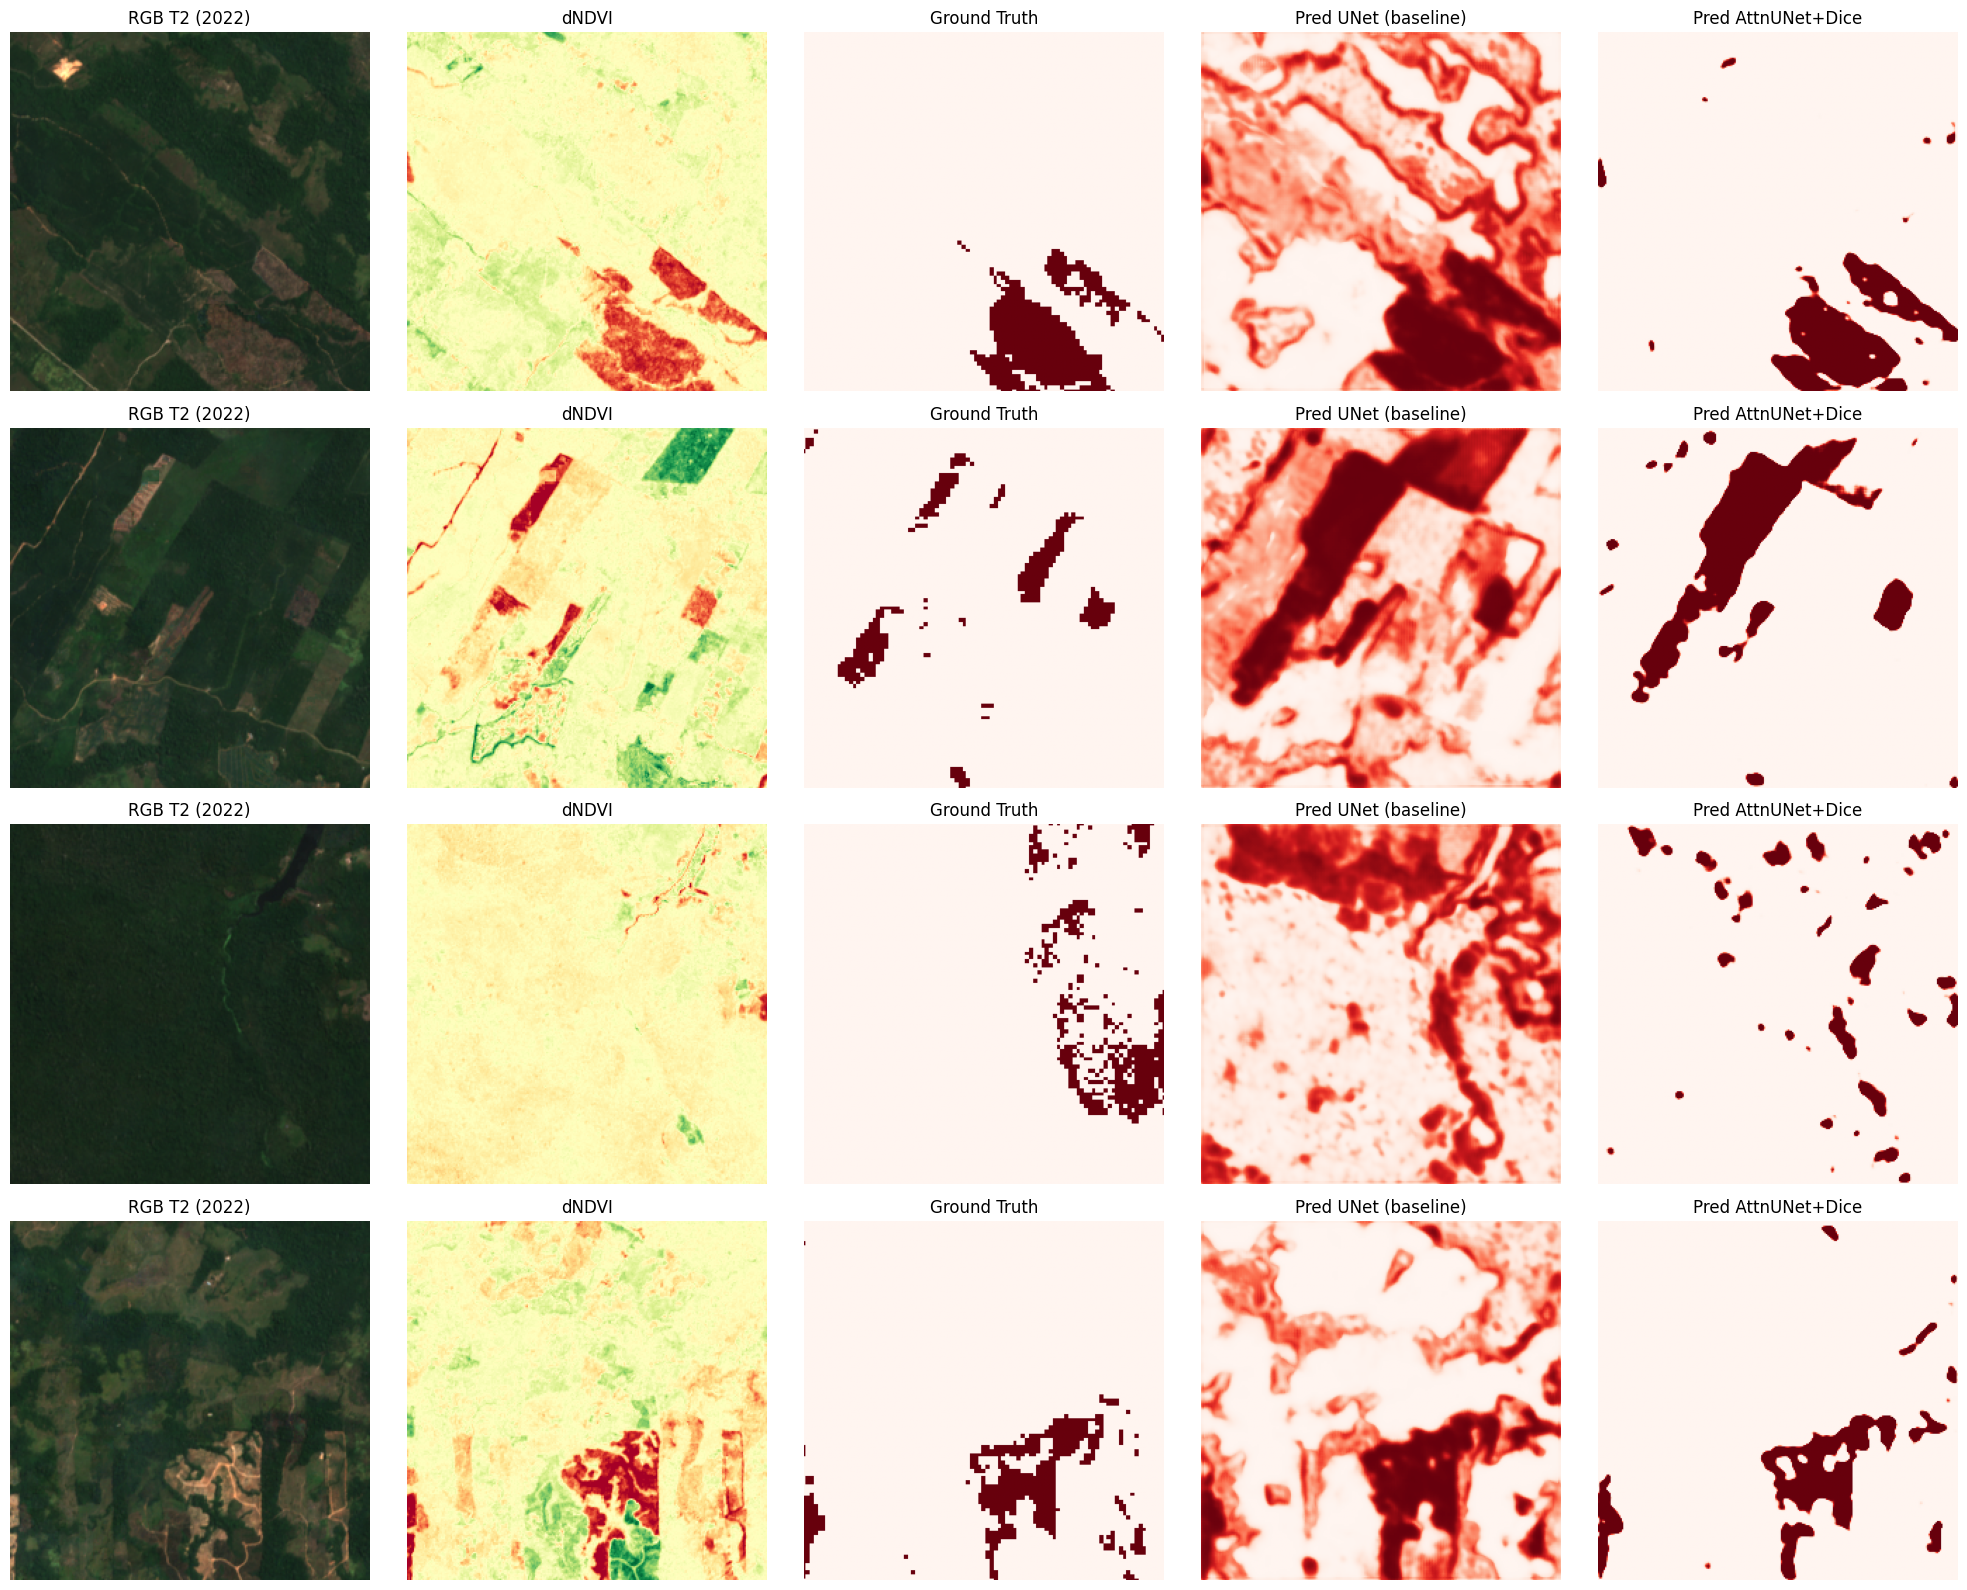

In [19]:
modelo_baseline = UNet(c_in=12, c_out=1, base=32); modelo_baseline.load_state_dict(torch.load(ruta_baseline)); modelo_baseline.to(device).eval()
modelo_attn     = AttentionUNet(c_in=12, c_out=1, base=32); modelo_attn.load_state_dict(torch.load(ruta_attn)); modelo_attn.to(device).eval()

ejemplos = []
for r in rutas_test:
    if np.load(r)[12].mean() > 0.05: ejemplos.append(r)
    if len(ejemplos) >= 4: break

fig, axes = plt.subplots(len(ejemplos), 5, figsize=(20, 4*len(ejemplos)))
if len(ejemplos) == 1: axes = axes[None, :]
with torch.no_grad():
    for i, ruta in enumerate(ejemplos):
        arr = np.load(ruta); x_raw = arr[:12]; y = arr[12]
        x_norm = ((x_raw - media[:,None,None])/(std[:,None,None]+1e-6)).astype(np.float32)
        x_t = torch.from_numpy(x_norm).unsqueeze(0).to(device)
        pred_b = torch.sigmoid(modelo_baseline(x_t))[0,0].cpu().numpy()
        pred_a = torch.sigmoid(modelo_attn(x_t))[0,0].cpu().numpy()
        rgb_t2 = np.clip(np.stack([x_raw[8],x_raw[7],x_raw[6]],axis=-1)/0.3, 0, 1)
        axes[i,0].imshow(rgb_t2); axes[i,0].set_title('RGB T2 (2022)')
        axes[i,1].imshow(x_raw[10]-x_raw[4], cmap='RdYlGn', vmin=-0.5, vmax=0.5); axes[i,1].set_title('dNDVI')
        axes[i,2].imshow(y, cmap='Reds'); axes[i,2].set_title('Ground Truth')
        axes[i,3].imshow(pred_b, cmap='Reds', vmin=0, vmax=1); axes[i,3].set_title('Pred UNet (baseline)')
        axes[i,4].imshow(pred_a, cmap='Reds', vmin=0, vmax=1); axes[i,4].set_title('Pred AttnUNet+Dice')
        for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.savefig(f'{DIR_RESULTADOS}/comparacion_visual.png', dpi=120, bbox_inches='tight'); plt.show()

## Celda 13 — Curvas de aprendizaje (3 modelos)

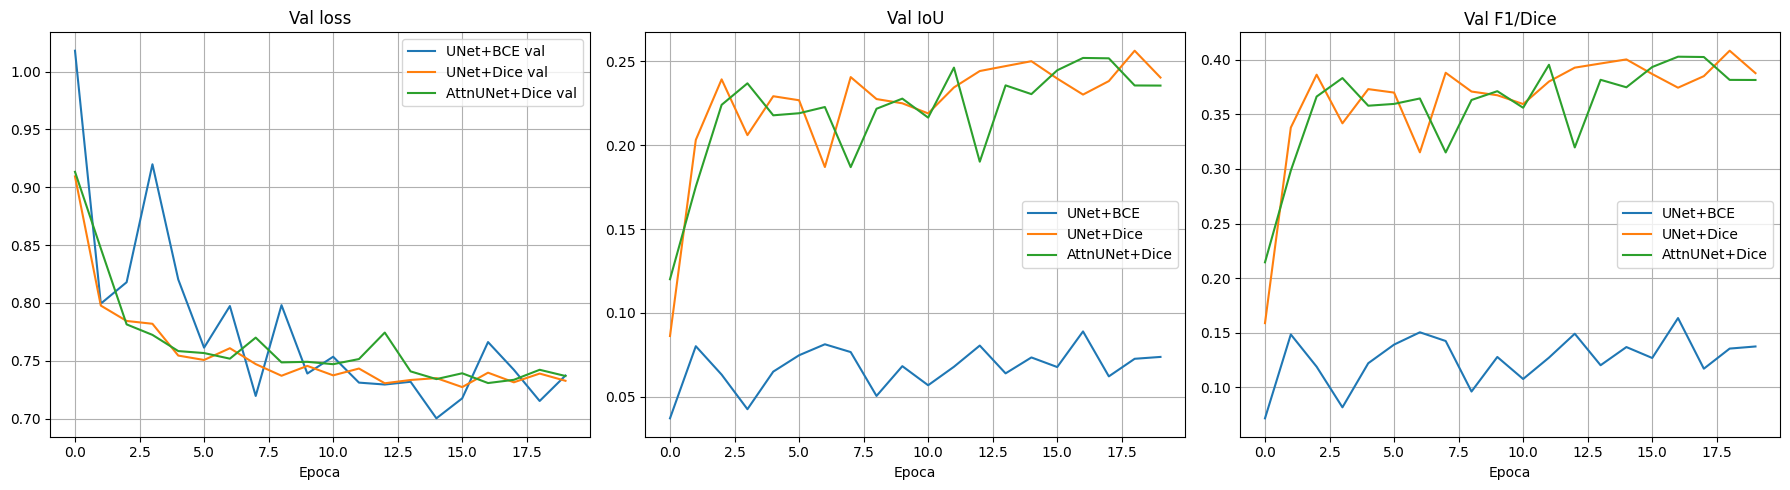

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for h, lab in [(hist_baseline,'UNet+BCE'), (hist_unet_dice,'UNet+Dice'), (hist_attn,'AttnUNet+Dice')]:
    axes[0].plot(h['val_loss'], label=lab+' val')
    axes[1].plot(h['val_iou'], label=lab)
    axes[2].plot(h['val_f1'], label=lab)
axes[0].set_title('Val loss'); axes[1].set_title('Val IoU'); axes[2].set_title('Val F1/Dice')
for ax in axes: ax.set_xlabel('Epoca'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig(f'{DIR_RESULTADOS}/curvas_aprendizaje.png', dpi=120, bbox_inches='tight'); plt.show()